#                                                                        Exploratory Data Analysis (EDA) + Profiling


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load dataset

df = pd.read_csv("../data/walmart_products_sample_5000.csv")

In [3]:
# Shape of data

print("Shape:", df.shape)


Shape: (5000, 8)


In [4]:
# Preview

display(df.head())

,Gtin,Brand,Product Name,Description,List Price,Package Size,Category,Product Url
0,28478129474,Crosman Archery,CenterPoint Sentinel Long Bow Set ABY215,We aim to show you accurate product informati...,37.42,NaN,Sports & Outdoors | Outdoor Sports | Hunting |...,https://www.walmart.com/ip/CenterPoint-Sentine...
1,403371886,Dilwe,Dilwe 7W E27 Smart Bluetooth Rgb Color Changin...,We aim to show you accurate product informati...,10.54,NaN,Household Essentials | Light Bulbs | Smart Bulbs,https://www.walmart.com/ip/Dilwe-7W-E27-Smart-...
2,641275538562,Little Things Mean a Lot,Boys Polyrayon Gabardine Bib with Button Accen...,We aim to show you accurate product informati...,16.00,NaN,Baby | Feeding | Bibs and Burp Cloths,https://www.walmart.com/ip/Boys-Polyrayon-Gaba...
3,244644791,College Inn,(2 Pack) College Inn Chicken Bold Stock 32oz,We aim to show you accurate product informati...,6.65,NaN,"Food | Meal Solutions, Grains & Pasta | Canned...",https://www.walmart.com/ip/2-Pack-College-Inn-...
4,858098007094,CREMO,"Cremo Astonishingly Superior Shave Cream, Bour...",We aim to show you accurate product informatio...,5.97,NaN,Personal Care | Personal Care by Brand | Cremo,https://www.walmart.com/ip/Cremo-Astonishingly...


In [5]:
# Column info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Gtin          5000 non-null   int64  
 1   Brand         4930 non-null   object 
 2   Product Name  5000 non-null   object 
 3   Description   5000 non-null   object 
 4   List Price    5000 non-null   float64
 5   Package Size  0 non-null      float64
 6   Category      4997 non-null   object 
 7   Product Url   5000 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 312.6+ KB


In [6]:
# Missing values

missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values:\n", missing)

Missing values:
 Package Size    5000
Brand             70
Category           3
Gtin               0
Product Name       0
Description        0
List Price         0
Product Url        0
dtype: int64


In [7]:
# Duplicates (check GTIN)

print("Duplicate GTINs:", df.duplicated(subset=["Gtin"]).sum())

Duplicate GTINs: 1


In [8]:
# Gtin range

min_length = df['Gtin'].astype(str).str.len().min()
max_length = df['Gtin'].astype(str).str.len().max()

print(f"Min GTIN length: {min_length}")
print(f"Max GTIN length: {max_length}")

Min GTIN length: 6
Max GTIN length: 12


In [9]:
# Summary stats

display(df.describe(include="all"))

,Gtin,Brand,Product Name,Description,List Price,Package Size,Category,Product Url
count,5.000000e+03,4930,5000,5000,5000.000000,0.0,4997,5000
unique,NaN,3212,4996,4968,NaN,NaN,1659,5000
top,NaN,Generic,10 Height Adjustable Portable Basketball Hoop ...,We aim to show you accurate product informatio...,NaN,NaN,Sports & Outdoors | Bikes | Bike Components | ...,https://www.walmart.com/ip/CenterPoint-Sentine...
freq,NaN,56,2,10,NaN,NaN,49,1
mean,4.451869e+11,NaN,NaN,NaN,78.203680,NaN,NaN,NaN
std,3.508102e+11,NaN,NaN,NaN,457.704528,NaN,NaN,NaN
min,1.830620e+05,NaN,NaN,NaN,0.370000,NaN,NaN,NaN
25%,4.261788e+10,NaN,NaN,NaN,11.120000,NaN,NaN,NaN
50%,6.392662e+11,NaN,NaN,NaN,21.310000,NaN,NaN,NaN
75%,7.544799e+11,NaN,NaN,NaN,46.800000,NaN,NaN,NaN


C:\Users\satis\AppData\Local\Temp\ipykernel_27576\3593586613.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bin_counts.index, y=bin_counts.values, palette="Blues_d")


Text(0, 0.5, 'Number of Products')

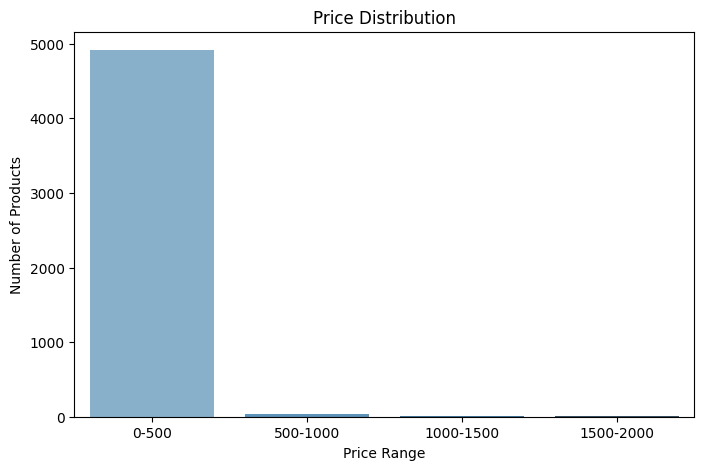

In [10]:
# Price distribution

# Define custom bins
bins = [0, 500, 1000, 1500, 2000]
bin_labels = ['0-500', '500-1000', '1000-1500', '1500-2000']

# Cut prices into bins
df_price_binned = pd.cut(df["List Price"], bins=bins, labels=bin_labels, include_lowest=True)

# Count products in each bin
bin_counts = df_price_binned.value_counts().sort_index()

# Plot bar chart (better for few bins)
plt.figure(figsize=(8,5))
sns.barplot(x=bin_counts.index, y=bin_counts.values, palette="Blues_d")
plt.title("Price Distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of Products")

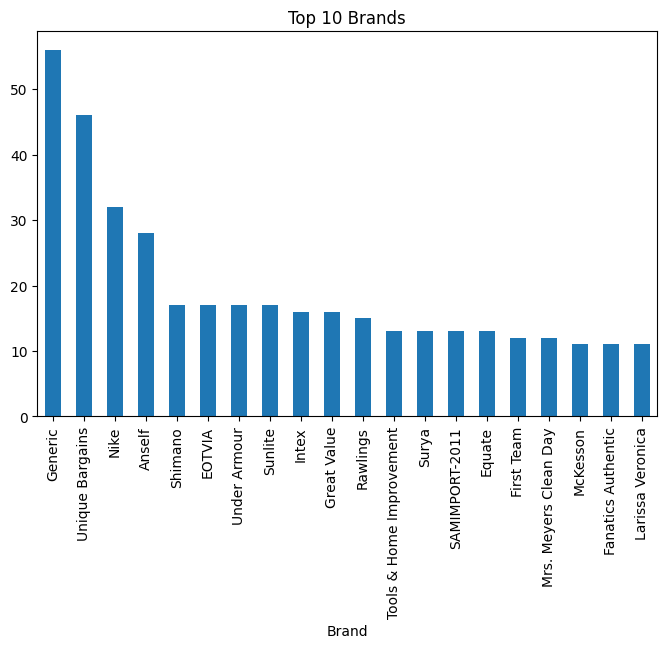

In [11]:
# Brand distribution

plt.figure(figsize=(8,5))
df["Brand"].value_counts().head(20).plot(kind="bar")
plt.title("Top 10 Brands")
plt.show()

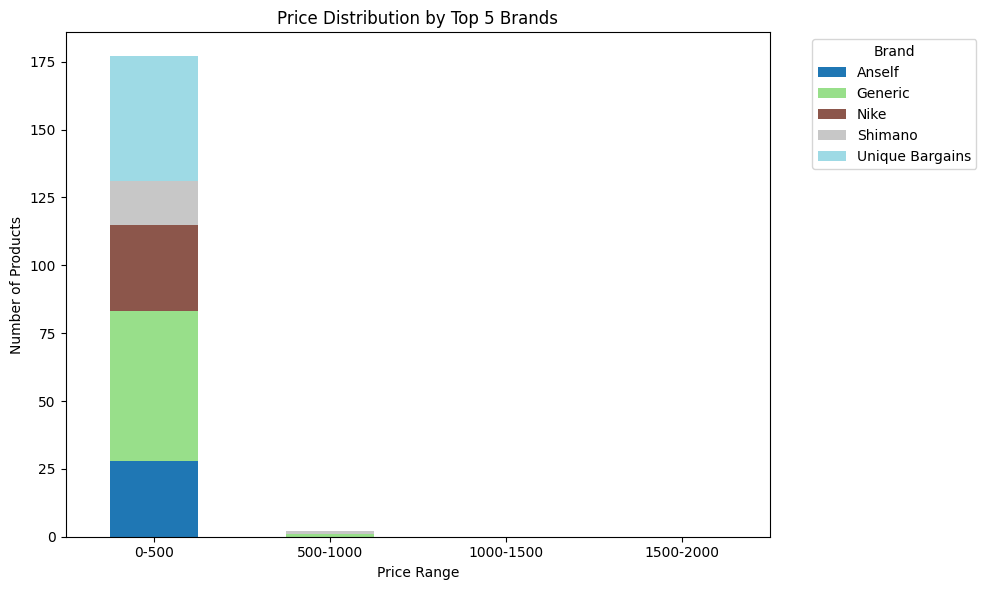

In [12]:
# Define bins
bins = [0, 500, 1000, 1500, 2000]
bin_labels = ['0-500', '500-1000', '1000-1500', '1500-2000']
df['Price_Bin'] = pd.cut(df['List Price'], bins=bins, labels=bin_labels, include_lowest=True)

# Select top 5 brands by count
top_brands = df['Brand'].value_counts().head(5).index
df_top = df[df['Brand'].isin(top_brands)]

# Create a pivot table: Price Bin vs Brand counts
pivot = df_top.pivot_table(index='Price_Bin', columns='Brand', aggfunc='size', fill_value=0)

# Plot stacked bar chart
pivot.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.title("Price Distribution by Top 5 Brands")
plt.xlabel("Price Range")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)

# Add legend on top
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

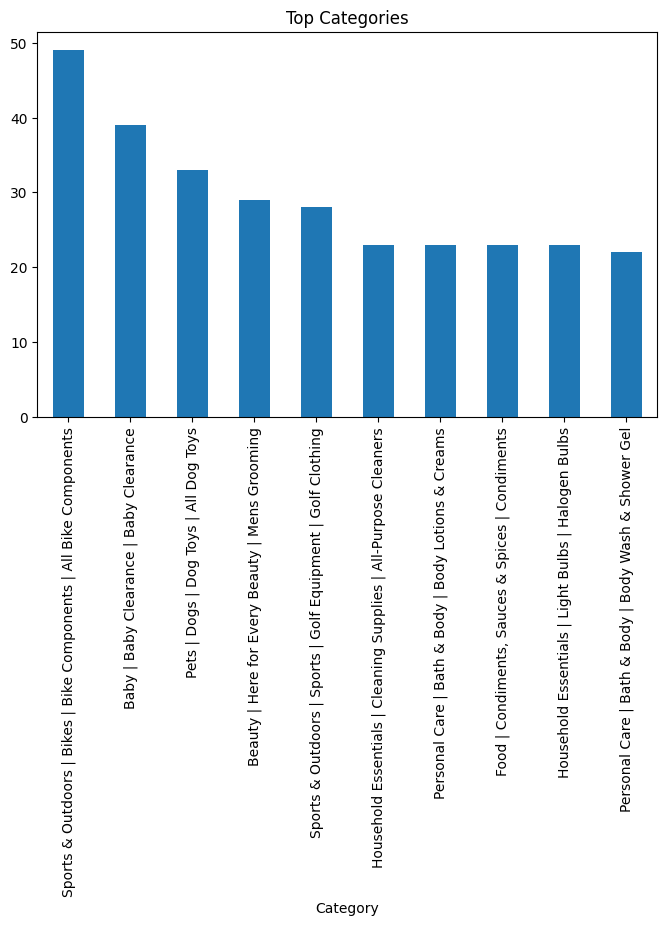

In [13]:
# Category distribution

plt.figure(figsize=(8,5))
df["Category"].value_counts().head(10).plot(kind="bar")
plt.title("Top Categories")
plt.show()

## Data Analysis and Observations

### Issues Identified

#### GTIN Format Issues:

- **Scientific Notation:** GTINs are stored in scientific format and need to be converted to standard numeric format
- **Invalid Length Range:** Current GTIN lengths range from 6-12 digits, which is incorrect
        - **Expected:** GTINs should typically be 12-14 digits long (GTIN-12, GTIN-13, or GTIN-14)
        - **Current:** 6-12 digit range suggests data corruption or incomplete values


#### Data Quality Issues:

- **Brand Names:** Inconsistent capitalization and special characters present
- **Product Names:** Require proper capitalization and special character removal
- **Missing Brand Information:** Empty brand name fields that could be populated from product names
- **Size Extraction:** Size column is currently empty but size information exists within product names
- **Description Redundancy:** Description column contains redundant information that needs cleanup


### Action Items

- ![High](https://img.shields.io/badge/Priority-High-red) **Fix GTIN Format:** Convert from scientific notation to standard numeric format  
- ![High](https://img.shields.io/badge/Priority-High-red) **Investigate Short GTINs:** Research why GTINs are shorter than standard (6-12 vs 12-14 digits)  
- ![High](https://img.shields.io/badge/Priority-High-red) **Validate Data Source:** Confirm if truncated GTINs are due to data export issues  
- ![Medium](https://img.shields.io/badge/Priority-Medium-yellow) **Standardize Brand Names:** Implement consistent capitalization rules  
- ![Medium](https://img.shields.io/badge/Priority-Medium-yellow) **Clean Product Names:** Remove special characters and apply proper formatting  
- ![Medium](https://img.shields.io/badge/Priority-Medium-yellow) **Extract Missing Brands:** Develop logic to populate brands from product names  
- ![Medium](https://img.shields.io/badge/Priority-Medium-yellow) **Size Extraction:** Create regex patterns to extract sizes from product names  
- ![Low](https://img.shields.io/badge/Priority-Low-green) **Description Cleanup:** Remove redundant information and standardize format  
- ![Low](https://img.shields.io/badge/Priority-Low-green) **Data Quality Metrics:** Implement ongoing data quality monitoring  
